In [1]:
import pandas as pd
import torch

df = pd.read_csv("sphere_dataset.csv")

X = torch.tensor(df[["x1", "x2", "x3"]].values, dtype=torch.float32)
Y = torch.tensor(df[["y1", "y2", "y3"]].values, dtype=torch.float32)

print(X.shape)
print(Y.shape)

torch.Size([10000, 3])
torch.Size([10000, 3])


In [2]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X, Y)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

7000
1500
1500


In [3]:
import torch.nn as nn

class SphereNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(3,20),
            nn.ReLU(),

            nn.Linear(20,20),
            nn.ReLU(),

            nn.Linear(20,3)

        )

    def forward(self,x):
        return self.model(x)

model = SphereNet()

In [4]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [5]:
epochs = 100

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    ####################
    # Training
    ####################

    model.train()

    total_loss = 0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        prediction = model(x_batch)

        loss = criterion(prediction, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    ####################
    # Validation
    ####################

    model.eval()

    total_val = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            prediction = model(x_batch)

            loss = criterion(prediction, y_batch)

            total_val += loss.item()

    val_loss = total_val / len(val_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(epoch,
          train_loss,
          val_loss)

0 0.2737249954180284 0.18686804796258608
1 0.11627499339255419 0.06155589781701565
2 0.04654411958022551 0.03941165469586849
3 0.03449707495217973 0.03082204159970085
4 0.027072193879972804 0.024263357433180015
5 0.021315646137703547 0.01888459858795007
6 0.01670104023069143 0.014856223327418169
7 0.013265242258256132 0.011800561177854737
8 0.010631161437115885 0.009531897376291454
9 0.008703665630045262 0.007864960042449335
10 0.0072305508465929464 0.006609269340212147
11 0.006157727264375849 0.005728280113544315
12 0.005403869235041467 0.005126200461139281
13 0.004859828915108334 0.004657120230452468
14 0.004440861809152094 0.004331038740929216
15 0.00417677382091907 0.004076635406818241
16 0.0039110517467964775 0.003838083182927221
17 0.003725853234275498 0.0036747332584733763
18 0.0035542446484958584 0.0035288562454904118
19 0.003404850580475547 0.003401722409762442
20 0.003284584553065625 0.00328900861980704
21 0.0031955687879500062 0.0031890792306512594
22 0.003098554087972099 0.

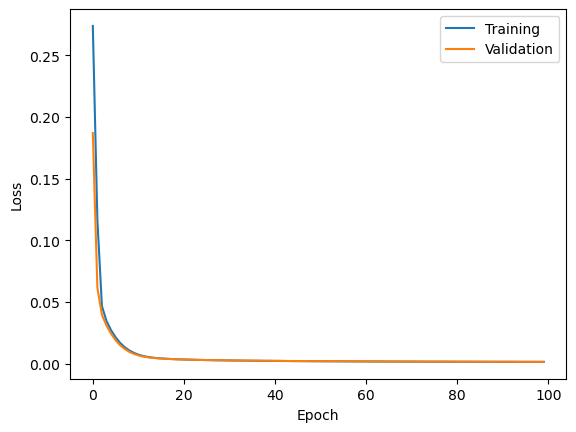

In [7]:
import matplotlib.pyplot as plt
plt.plot(train_loss_history,label="Training")
plt.plot(val_loss_history,label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [8]:
model.eval()

total = 0

with torch.no_grad():

    for x_batch,y_batch in test_loader:

        pred = model(x_batch)

        total += criterion(pred,y_batch).item()

test_loss = total/len(test_loader)

print("Test Loss =",test_loss)

Test Loss = 0.0012728094346433256
